# HumanEvalComm refinement: analysis

This notebook analyses the results of the clarifying-question refinement pipeline for one coder
model. It reads the two analysis files written by `data_analysis.build_baseline_data` and
`data_analysis.build_complete_data` (step 7 in `run.py`):

- `.HEC-experiment/<MODEL>/analysis/baseline_data_<category>.json`: every baseline task.
- `.HEC-experiment/<MODEL>/analysis/complete_data_<category>.json`: every refined task with its
  baseline and all question branches (`q1`–`q3`, each with `desc1`, `desc2` and `oracle`).

To analyse another model, change `MODEL` below and run all cells. All results are deterministic:
where a strategy picks a question at random, or breaks a tie at random, the notebook computes
the exact expectation over all choices instead of drawing one.

**Sections**

1. Baseline: incoherence vs. error
2. Error reduction per question
3. Does marking predict helpfulness?
4. Incoherence reduction vs. error reduction
5. Marked and helpful questions per task
6. Question selection strategies
7. Sensitivity to the significance level

In [1]:
import json
import statistics

import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from scipy import stats

from common import EXPERIMENT
from plot_style import *

MODEL         = "Qwen3CoderNext"   # a key of CODER_MODELS in common.py
CATEGORIES    = ["1c"]             # categories with both a baseline and a refined phase
NUM_QUESTIONS = 3                  # coder questions per task (q1, q2, q3)
ALPHA         = 0.05               # significance level for "marked" and "helpful"

ANALYSIS_DIR = EXPERIMENT / MODEL / "analysis"

def load(name):
    with open(ANALYSIS_DIR / name, encoding="utf-8") as f:
        return json.load(f)

BASELINE = {c: load(f"baseline_data_{c}.json") for c in CATEGORIES}
COMPLETE = {c: load(f"complete_data_{c}.json") for c in CATEGORIES}

## Definitions

Every task was run 10 times. Each run gives one incoherence and one error value per condition,
so every condition has a list of up to 10 values, one per run (`incoherence_list`, `error_list`).
Significance is tested with a **one-sided Mann-Whitney U test** between two such lists.

For each task and each question `q1`–`q3`, the pipeline produced three refined conditions:

| Branch | Clarification appended to the task | Metrics |
| --- | --- | --- |
| `desc1` | the coder's own answer, assuming YES | incoherence |
| `desc2` | the coder's own answer, assuming NO | incoherence |
| `oracle` | the oracle's true answer | incoherence and error |

From these, every question gets three labels:

- **Marked** (predicted helpful, needs no ground truth): the incoherence of **both** `desc1` and
  `desc2` is significantly lower than the baseline incoherence (level `ALPHA`). Whatever the answer is, it makes the coder more coherent, so the question
  seems to resolve an ambiguity.
- **Helpful** (ground truth): the error of the `oracle` branch is significantly lower than the
  baseline error.

Two reductions are used throughout (positive = improvement):

- **Incoherence reduction**: baseline mean incoherence − mean of the `desc1` and `desc2` mean
  incoherences.
- **Error reduction**: baseline mean error − `oracle` mean error.

For each task, the **best marked** questions are the marked questions with the largest
incoherence reduction, and the **best helpful** questions are the helpful questions with the
largest error reduction. Both sets contain all tied questions.

In [2]:
def _valid(values):
    return [v for v in values if v is not None]

def significantly_lower(baseline, sample, alpha=ALPHA):
    # One-sided MWU: True if `sample` is significantly lower than `baseline` and its mean is not higher.
    bl, s = _valid(baseline), _valid(sample)
    p = stats.mannwhitneyu(s, bl, alternative="less").pvalue
    return p < alpha and statistics.mean(bl) >= statistics.mean(s)

def significantly_higher(baseline, sample, alpha=ALPHA):
    # One-sided MWU: True if `sample` is significantly higher than `baseline` and its mean is not lower.
    bl, s = _valid(baseline), _valid(sample)
    p = stats.mannwhitneyu(s, bl, alternative="greater").pvalue
    return p < alpha and statistics.mean(s) >= statistics.mean(bl)

def question_stats(task, alpha=ALPHA, alpha_helpful=None):
    # One row per question of `task`: reductions and the marked / helpful / harmful labels.
    # `alpha` is the level for "marked", `alpha_helpful` (default: alpha) for "helpful" and "harmful".
    alpha_helpful = alpha if alpha_helpful is None else alpha_helpful
    bl = task["baseline"]
    rows = []
    for i in range(1, NUM_QUESTIONS + 1):
        qk = f"q{i}"
        d1, d2, orc = (task["refined"][f"{qk}_{b}"] for b in ("desc1", "desc2", "oracle"))
        refined_inc = statistics.mean([d1["mean_incoherence"], d2["mean_incoherence"]])
        err_red = bl["mean_error"] - orc["mean_error"]
        rows.append({
            "q_id":         qk,
            "task_id":      task["task_id"],
            "bl_err_mean":  bl["mean_error"],
            "orc_err_mean": orc["mean_error"],
            "inc_red_abs":  bl["mean_incoherence"] - refined_inc,
            "err_red_abs":  err_red,
            "err_red_rel":  err_red / bl["mean_error"] * 100 if bl["mean_error"] > 0 else None,
            "marked":  (significantly_lower(bl["incoherence_list"], d1["incoherence_list"], alpha) and
                        significantly_lower(bl["incoherence_list"], d2["incoherence_list"], alpha)),
            "helpful": significantly_lower(bl["error_list"], orc["error_list"], alpha_helpful),
            "harmful": significantly_higher(bl["error_list"], orc["error_list"], alpha_helpful),
        })
    return rows

def _best(rows, key):
    # All rows with the maximum value of `key` (empty if `rows` is empty).
    if not rows:
        return []
    top = max(r[key] for r in rows)
    return [r for r in rows if r[key] == top]

def get_stats(tasks, alpha=ALPHA, alpha_helpful=None):
    # Returns (per-question rows, per-task rows) for a list of complete_data tasks.
    per_question, per_task = [], []
    for task in tasks:
        questions = question_stats(task, alpha, alpha_helpful)
        per_question.extend(questions)
        per_task.append({
            "task_id":      task["task_id"],
            "name":         task["name"],
            "bl_err_mean":  task["baseline"]["mean_error"],
            "questions":    questions,
            "best_marked":  _best([q for q in questions if q["marked"]],  "inc_red_abs"),
            "best_helpful": _best([q for q in questions if q["helpful"]], "err_red_abs"),
        })
    return per_question, per_task

SPQ, SPT = {}, {}   # per category: stats per question, stats per task (at level ALPHA)
for c in CATEGORIES:
    SPQ[c], SPT[c] = get_stats(COMPLETE[c])

## 1. Baseline: incoherence vs. error

How well does incoherence track error before any refinement? For every baseline task that has
both a mean incoherence and a mean error, the table shows the means over tasks, the Spearman
rank correlation between the two, and how many tasks have a non-zero value.

This uses `baseline_data`, so it covers all baseline tasks, not only the refined ones.

In [3]:
t = PrettyTable(["Category", "Mean incoherence", "Mean error", "Spearman(inc, err)",
                 "n tasks (inc + err)", "n tasks with inc > 0", "n tasks with err > 0"])
for c in CATEGORIES:
    pairs = [(x["mean_incoherence"], x["mean_error"]) for x in BASELINE[c]
             if x["mean_incoherence"] is not None and x["mean_error"] is not None]
    inc_vals, err_vals = zip(*pairs)
    rho, p_rho = stats.spearmanr(inc_vals, err_vals)
    t.add_row([c, f"{statistics.mean(inc_vals):.3f}", f"{statistics.mean(err_vals):.3f}",
               f"{rho:.2f} (p={p_rho:.1g})", len(pairs),
               sum(i > 0 for i in inc_vals), sum(e > 0 for e in err_vals)])
print(t)

+----------+------------------+------------+--------------------+---------------------+----------------------+----------------------+
| Category | Mean incoherence | Mean error | Spearman(inc, err) | n tasks (inc + err) | n tasks with inc > 0 | n tasks with err > 0 |
+----------+------------------+------------+--------------------+---------------------+----------------------+----------------------+
|    1c    |      0.166       |   0.242    |   0.84 (p=2e-41)   |         148         |         115          |         123          |
+----------+------------------+------------+--------------------+---------------------+----------------------+----------------------+


## 2. Error reduction per question

How much does answering a question with the oracle's true answer reduce the error? The table
compares three sets of questions: all questions, the marked ones and the helpful ones.

- **Mean % / Median %**: mean and median of the per-question relative error reduction
  (questions with a baseline error of 0 are left out).
- **Pooled reduction %**: relative reduction of the mean error over the set, i.e.
  (mean baseline error − mean oracle error) / mean baseline error. Unlike the mean of
  percentages, this weights tasks by their baseline error.

The scatter plot shows the marked questions only: baseline error against oracle error, coloured
by their ground-truth label. Points below the diagonal improved.

Per-question error reduction:
+-------------------+--------+----------+---------------------+-------------------+--------------------+
| Scenario          | Mean % | Median % | Mean baseline error | Mean oracle error | Pooled reduction % |
+-------------------+--------+----------+---------------------+-------------------+--------------------+
| All Questions     | -34.81 |  27.39   |         0.30        |        0.22       |       27.09        |
| Marked Questions  | 58.43  |  72.65   |         0.41        |        0.21       |       48.86        |
| Helpful Questions | 62.93  |  71.54   |         0.35        |        0.16       |       55.54        |
+-------------------+--------+----------+---------------------+-------------------+--------------------+


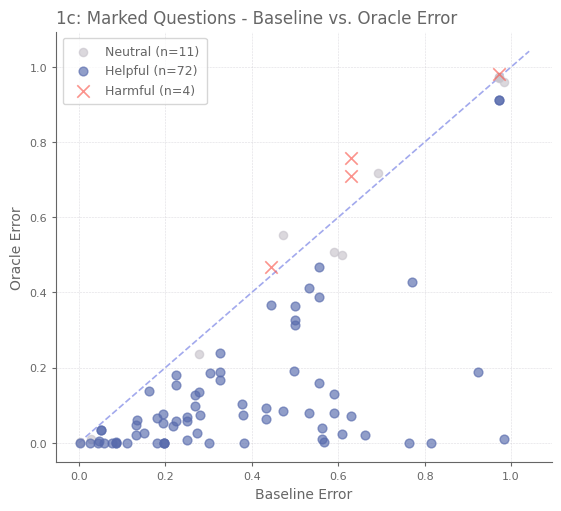

In [4]:
def pooled_reduction(rows):
    valid = [q for q in rows if q["bl_err_mean"] and q["orc_err_mean"] is not None]
    bl  = statistics.mean(q["bl_err_mean"]  for q in valid)
    orc = statistics.mean(q["orc_err_mean"] for q in valid)
    return bl, orc, (bl - orc) / bl * 100

def plot_baseline_vs_oracle(groups, title=None):
    # Scatter of baseline error vs. oracle error. groups: (rows, color, label, marker, size).
    _, ax = plt.subplots(figsize=(5.5, 5))
    all_vals = [v for rows, *_ in groups for r in rows
                for v in (r["bl_err_mean"], r["orc_err_mean"]) if v is not None]
    lim = max(all_vals) * 1.06
    ax.plot([0, lim], [0, lim], color=LIGHT_BLUE, zorder=2)
    for rows, color, label, marker, size in groups:
        if rows:
            ax.scatter([r["bl_err_mean"] for r in rows], [r["orc_err_mean"] for r in rows],
                       c=color, label=f"{label} (n={len(rows)})", s=size, alpha=0.65, marker=marker, zorder=3)
    ax.set_xlabel("Baseline Error")
    ax.set_ylabel("Oracle Error")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=9)
    plt.show()

for c in CATEGORIES:
    spq    = SPQ[c]
    marked = [q for q in spq if q["marked"]]
    t = PrettyTable(["Scenario", "Mean %", "Median %", "Mean baseline error", "Mean oracle error",
                     "Pooled reduction %"])
    t.align["Scenario"] = "l"
    for label, rows in [("All Questions",     spq),
                        ("Marked Questions",  marked),
                        ("Helpful Questions", [q for q in spq if q["helpful"]])]:
        reductions = [q["err_red_rel"] for q in rows if q["err_red_rel"] is not None]
        if not reductions:
            t.add_row([label, "-", "-", "-", "-", "-"])
            continue
        bl, orc, red = pooled_reduction(rows)
        t.add_row([label, f"{statistics.mean(reductions):.2f}", f"{statistics.median(reductions):.2f}",
                   f"{bl:.2f}", f"{orc:.2f}", f"{red:.2f}"])
    print(f"Per-question error reduction:")
    print(t)
    plot_baseline_vs_oracle([
        ([q for q in marked if not q["helpful"] and not q["harmful"]], NEUTRAL_COLOR, "Neutral", "o", 35),
        ([q for q in marked if q["helpful"]],                          DARK_BLUE,     "Helpful", "o", 40),
        ([q for q in marked if q["harmful"]],                          DARK_SALMON,   "Harmful", "x", 80),
    ], title=f"{c}: Marked Questions - Baseline vs. Oracle Error")

## 3. Does marking predict helpfulness?

"Marked" is computed without the ground truth, "helpful" with it. This section treats marking
as a classifier for helpfulness, over all questions of all refined tasks:

- **P(helpful | marked)** vs. **P(helpful | not marked)**, with **Fisher's exact test** on the
  2×2 table (odds ratio OR and p-value) and the **phi coefficient** (equal to the Matthews
  correlation coefficient for a 2×2 table).
- The **confusion matrix** (rows: marked or not, columns: helpful or not).
- A **classification report** with precision, recall and F1 for both classes, where "helpful" is
  the positive class.

In [5]:
def fisher_and_report(spq, title=""):
    # Fisher's exact test, confusion matrix and classification report for marked -> helpful.
    def cell(m, h): return sum(1 for q in spq if q["marked"] == m and q["helpful"] == h)
    a, b, c, d = cell(True, True), cell(True, False), cell(False, True), cell(False, False)
    n = a + b + c + d
    or_, p = stats.fisher_exact([[a, b], [c, d]])
    denom = (a + b) * (c + d) * (a + c) * (b + d)
    phi = (a * d - b * c) / np.sqrt(denom) if denom else float("nan")

    print(f"=== {title} ===")
    print(f"P(helpful|marked)     = {a/(a+b):.3f}  ({a}/{a+b})" if (a+b) else "P(helpful|marked)     = -  (0/0)")
    print(f"P(helpful|not marked) = {c/(c+d):.3f}  ({c}/{c+d})" if (c+d) else "P(helpful|not marked) = -  (0/0)")
    print(f"OR = {or_:.2f}, p = {p:.3g}, phi = {phi:.3f}")

    t = PrettyTable(["", "helpful", "not helpful", "total"]); t.align = "r"; t.align[""] = "l"
    t.add_row(["marked", a, b, a + b]); t.add_row(["not marked", c, d, c + d]); t.add_row(["total", a + c, b + d, n])
    print("Confusion matrix (rows: prediction, columns: ground truth)"); print(t)

    def prf(tp, fp, fn):
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec  = tp / (tp + fn) if tp + fn else 0.0
        f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        return prec, rec, f1
    pos, neg = prf(a, b, c), prf(d, c, b)
    support_pos, support_neg = a + c, b + d
    accuracy = (a + d) / n if n else 0.0
    macro    = [statistics.mean(v) for v in zip(pos, neg)]
    weighted = [(support_pos * p_ + support_neg * n_) / n for p_, n_ in zip(pos, neg)] if n else [0, 0, 0]

    rep = PrettyTable(["Class", "Precision", "Recall", "F1", "Support"]); rep.align = "r"; rep.align["Class"] = "l"
    for name, (prec, rec, f1), sup in [("helpful", pos, support_pos), ("not helpful", neg, support_neg)]:
        rep.add_row([name, f"{prec:.3f}", f"{rec:.3f}", f"{f1:.3f}", sup])
    rep.add_row(["---"] * 5)
    rep.add_row(["accuracy", "", "", f"{accuracy:.3f}", n])
    rep.add_row(["macro avg", f"{macro[0]:.3f}", f"{macro[1]:.3f}", f"{macro[2]:.3f}", n])
    rep.add_row(["weighted avg", f"{weighted[0]:.3f}", f"{weighted[1]:.3f}", f"{weighted[2]:.3f}", n])
    print("Classification report (positive class = helpful, predictor = marked)"); print(rep); print()

for c in CATEGORIES:
    fisher_and_report(SPQ[c], c)

=== 1c ===
P(helpful|marked)     = 0.828  (72/87)
P(helpful|not marked) = 0.318  (81/255)
OR = 10.31, p = 6.61e-17, phi = 0.447
Confusion matrix (rows: prediction, columns: ground truth)
+------------+---------+-------------+-------+
|            | helpful | not helpful | total |
+------------+---------+-------------+-------+
| marked     |      72 |          15 |    87 |
| not marked |      81 |         174 |   255 |
| total      |     153 |         189 |   342 |
+------------+---------+-------------+-------+
Classification report (positive class = helpful, predictor = marked)
+--------------+-----------+--------+-------+---------+
| Class        | Precision | Recall |    F1 | Support |
+--------------+-----------+--------+-------+---------+
| helpful      |     0.828 |  0.471 | 0.600 |     153 |
| not helpful  |     0.682 |  0.921 | 0.784 |     189 |
| ---          |       --- |    --- |   --- |     --- |
| accuracy     |           |        | 0.719 |     342 |
| macro avg    |     0.

## 4. Incoherence reduction vs. error reduction

Does a larger drop in incoherence go with a larger drop in error? Each point is one question:
incoherence reduction (x) against error reduction (y), both absolute. Points in the upper right
reduced both.

The dashed line is an ordinary least squares fit over all questions; the Pearson and Spearman
correlations are shown in the top left. Marked questions that are harmful are drawn as crosses.

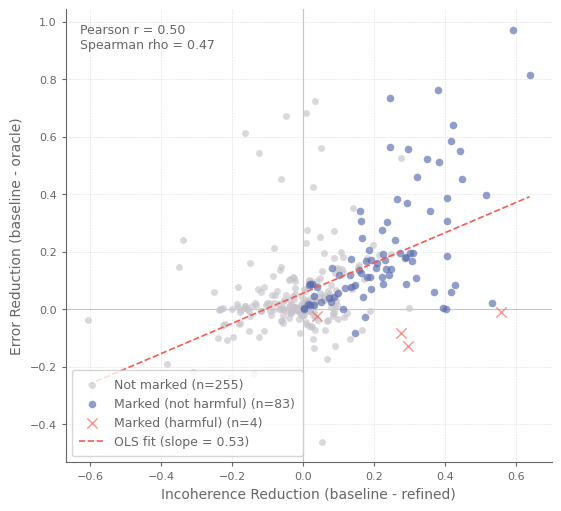

In [6]:
def plot_inc_vs_err(groups, fit_rows=None, title=None, figsize=(5.5, 5)):
    # Scatter of incoherence reduction vs. error reduction. fit_rows adds an OLS line and correlations.
    _, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, color=NEUTRAL_COLOR, linewidth=0.8, linestyle="-", zorder=1)
    ax.axvline(0, color=NEUTRAL_COLOR, linewidth=0.8, linestyle="-", zorder=1)
    for rows, color, label, marker, size in groups:
        if rows:
            ax.scatter([r["inc_red_abs"] for r in rows], [r["err_red_abs"] for r in rows],
                       c=color, label=f"{label} (n={len(rows)})", s=size, alpha=0.65,
                       marker=marker, linewidth=0 if marker == "o" else 1.0, zorder=3, rasterized=True)
    if fit_rows:
        x = np.array([r["inc_red_abs"] for r in fit_rows])
        y = np.array([r["err_red_abs"] for r in fit_rows])
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.array([x.min(), x.max()])
        ax.plot(xs, slope * xs + intercept, color=DARK_SALMON, linestyle="--", linewidth=1.2, zorder=4,
                label=f"OLS fit (slope = {slope:.2f})")
        r_p, _ = stats.pearsonr(x, y)
        rho, _ = stats.spearmanr(x, y)
        ax.text(0.03, 0.97, f"Pearson r = {r_p:.2f}\nSpearman rho = {rho:.2f}",
                transform=ax.transAxes, va="top", ha="left", fontsize=9, color=WARM_GRAY)
    ax.set_xlabel("Incoherence Reduction (baseline - refined)")
    ax.set_ylabel("Error Reduction (baseline - oracle)")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=9, loc="lower left")
    plt.show()

for c in CATEGORIES:
    spq = SPQ[c]
    plot_inc_vs_err([
        ([q for q in spq if not q["marked"]],                   NEUTRAL_COLOR, "Not marked",           "o", 25),
        ([q for q in spq if q["marked"] and not q["harmful"]],  DARK_BLUE,     "Marked (not harmful)", "o", 30),
        ([q for q in spq if q["marked"] and q["harmful"]],      DARK_SALMON,   "Marked (harmful)",     "x", 55),
    ], fit_rows=spq, title="")

## 5. Marked and helpful questions per task

How are marked and helpful questions spread over tasks? The histograms count how many tasks
have 0, 1, 2 or 3 helpful (left) and marked (right) questions. The dashed line is the mean
number per task.

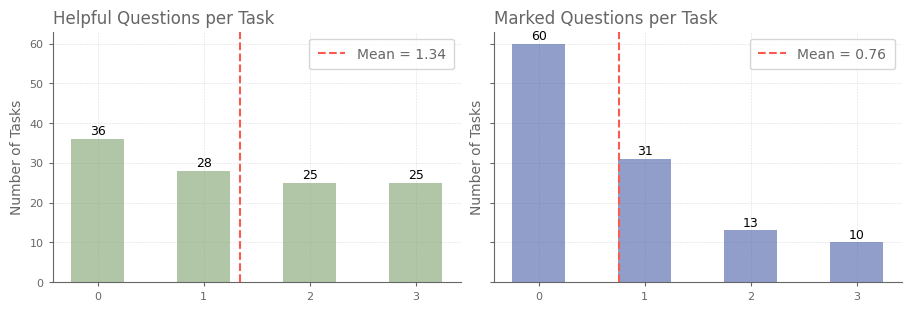

In [7]:
for c in CATEGORIES:
    spt = SPT[c]
    tasks_marked  = {t["task_id"]: 0 for t in spt}
    tasks_helpful = {t["task_id"]: 0 for t in spt}
    for t in spt:
        tasks_marked[t["task_id"]]  += len([q for q in t["questions"] if q["marked"]])
        tasks_helpful[t["task_id"]] += len([q for q in t["questions"] if q["helpful"]])
    x = list(range(NUM_QUESTIONS + 1))
    fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
    for ax, counts, color, title in [
        (axes[0], list(tasks_helpful.values()), MEDIUM_GREEN, f"Helpful Questions per Task"),
        (axes[1], list(tasks_marked.values()),  DARK_BLUE,    f"Marked Questions per Task"),
    ]:
        y = [sum(1 for c in counts if c == k) for k in x]
        bars = ax.bar(x, y, color=color, alpha=0.65, width=0.5, zorder=2)
        for bar, n in zip(bars, y):
            if n > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, n + 0.3, str(n), ha="center", va="bottom", fontsize=9)
        avg = statistics.mean([int(c) for c in counts])
        ax.axvline(avg, color=DARK_SALMON, linewidth=1.5, linestyle="--", label=f"Mean = {avg:.2f}")
        ax.set_xticks(x); ax.set_ylabel("Number of Tasks")
        ax.set_title(title, loc="left"); ax.legend()
    plt.show()

## 6. Question selection strategies

In practice, the coder may ask only one question at a time and does not know the true answer
in advance. This section compares two ways of choosing which question to ask:

- **Random Q only**: pick one of the three questions uniformly at random.
- **Best Q + Random fallback**: pick a best marked question (largest incoherence reduction). If
  the task has no marked question, pick one at random.

Both strategies involve random choices (the random pick, and ties among best marked questions).
Instead of drawing, the notebook averages over all choices exactly.

**Expected error.** For each task, the expected oracle error of the chosen question. The table
shows the mean and median over tasks, and the reduction relative to the mean baseline error.

**Hit rate.** Over the tasks with at least one helpful question: the probability that the
strategy picks one of the best helpful questions (largest error reduction among the helpful
ones, ties all count as hits).

In [8]:
def candidates(task, strategy):
    # The questions a strategy chooses from uniformly at random.
    if strategy == "combined" and task["best_marked"]:
        return task["best_marked"]
    return task["questions"]

def expected_error(task, strategy):
    return statistics.mean(q["orc_err_mean"] for q in candidates(task, strategy))

def expected_hit(task, strategy):
    best = {q["q_id"] for q in task["best_helpful"]}
    pool = candidates(task, strategy)
    return sum(q["q_id"] in best for q in pool) / len(pool)

STRATEGIES = [("Random Q only", "random"), ("Best Q + Random fallback", "combined")]

for c in CATEGORIES:
    spt     = SPT[c]
    mean_bl = statistics.mean(t["bl_err_mean"] for t in spt)
    n_marked_tasks = sum(1 for t in spt if t["best_marked"])
    print(f"=== {c}: {len(spt)} tasks, {n_marked_tasks} with a marked question "
          f"({len(spt) - n_marked_tasks} use the random fallback) ===")

    t = PrettyTable(["Strategy", "Mean Expected Error", "Abs. Reduction", "Rel. Reduction"])
    t.align["Strategy"] = "l"
    t.add_row(["Baseline", f"{mean_bl:.3f}", "-", "-"])
    for label, strategy in STRATEGIES:
        errs = [expected_error(task, strategy) for task in spt]
        m = statistics.mean(errs)
        t.add_row([label, f"{m:.3f}", f"{mean_bl - m:.3f}", f"{(mean_bl - m) / mean_bl * 100:.1f}%"])
    print(t)

    with_helpful = [task for task in spt if task["best_helpful"]]
    h = PrettyTable(["Strategy", "Hit rate"])
    h.align["Strategy"] = "l"
    for label, strategy in STRATEGIES:
        h.add_row([label, f"{statistics.mean(expected_hit(task, strategy) for task in with_helpful):.1%}"])
    print(f"Tasks with at least one helpful question: {len(with_helpful)}")
    print(h)

=== 1c: 114 tasks, 54 with a marked question (60 use the random fallback) ===
+--------------------------+---------------------+----------------+----------------+
| Strategy                 | Mean Expected Error | Abs. Reduction | Rel. Reduction |
+--------------------------+---------------------+----------------+----------------+
| Baseline                 |        0.299        |       -        |       -        |
| Random Q only            |        0.218        |     0.081      |     27.1%      |
| Best Q + Random fallback |        0.181        |     0.118      |     39.6%      |
+--------------------------+---------------------+----------------+----------------+
Tasks with at least one helpful question: 78
+--------------------------+----------+
| Strategy                 | Hit rate |
+--------------------------+----------+
| Random Q only            |  36.3%   |
| Best Q + Random fallback |  56.0%   |
+--------------------------+----------+


## 7. Sensitivity to the significance level

How much do the results in section 3 depend on the choice of `ALPHA = 0.05`? Both plots repeat
the classification for a range of significance levels α and show precision, recall and F1 of
"marked" as a predictor of "helpful", plus the share of questions that are marked and helpful
(right axis: the same share as a number of questions).

- **Sensitivity**: only the level for "marked" varies; "helpful" stays at `ALPHA`. This shows
  how the predictor behaves against a fixed ground truth.
- **Robustness**: both levels vary together, so the ground truth changes as well.

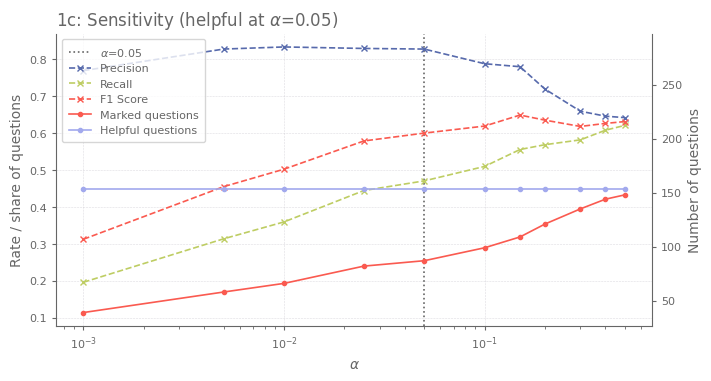

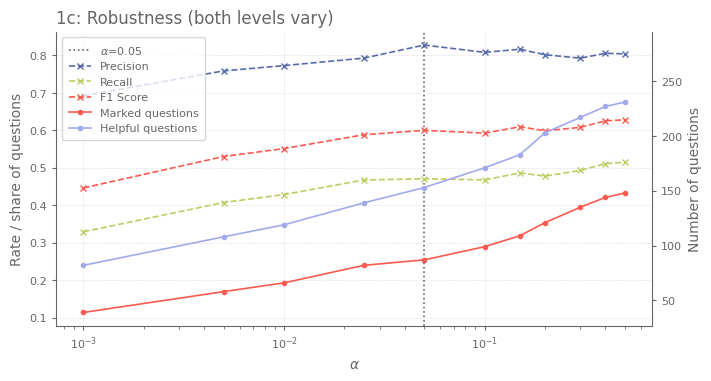

In [9]:
ALPHAS = [0.001, 0.005, 0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]

def alpha_sweep(tasks, alphas, alpha_helpful=None):
    # Precision / recall / F1 of marked -> helpful for each alpha. alpha_helpful=None varies both levels.
    res = {k: [] for k in ("precision", "recall", "f1", "n_marked", "n_helpful")}
    for a in alphas:
        spq, _ = get_stats(tasks, a, a if alpha_helpful is None else alpha_helpful)
        marked  = [q for q in spq if q["marked"]]
        helpful = [q for q in spq if q["helpful"]]
        tp = sum(1 for q in marked if q["helpful"])
        precision = tp / len(marked)  if marked  else 0.0
        recall    = tp / len(helpful) if helpful else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        for k, v in [("precision", precision), ("recall", recall), ("f1", f1),
                     ("n_marked", len(marked)), ("n_helpful", len(helpful))]:
            res[k].append(v)
    res["n_questions"] = len(spq)
    return res

def plot_alpha_sweep(alphas, res, title=None):
    n = res["n_questions"]
    _, ax = plt.subplots(figsize=(7, 3.7))
    ax.axvline(ALPHA, color=WARM_GRAY, linewidth=1.2, linestyle=":", label=rf"$\alpha$={ALPHA}")
    ax.plot(alphas, res["precision"], marker="x", markersize=5, color=DARK_BLUE,   label="Precision")
    ax.plot(alphas, res["recall"],    marker="x", markersize=5, color=SAGE_GREEN,  label="Recall")
    ax.plot(alphas, res["f1"],        marker="x", markersize=5, color=DARK_SALMON, label="F1 Score")
    ax.plot(alphas, [k / n for k in res["n_marked"]],  marker="o", markersize=3, color=DARK_SALMON,
            linestyle="-", label="Marked questions")
    ax.plot(alphas, [k / n for k in res["n_helpful"]], marker="o", markersize=3, color=LIGHT_BLUE,
            linestyle="-", label="Helpful questions")
    ax.set_xscale("log")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Rate / share of questions")
    secax = ax.secondary_yaxis("right", functions=(lambda x: x * n, lambda x: x / n))
    secax.set_ylabel("Number of questions")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=8)
    plt.show()

for c in CATEGORIES:
    plot_alpha_sweep(ALPHAS, alpha_sweep(COMPLETE[c], ALPHAS, alpha_helpful=ALPHA),
                     title=rf"{c}: Sensitivity (helpful at $\alpha$={ALPHA})")
    plot_alpha_sweep(ALPHAS, alpha_sweep(COMPLETE[c], ALPHAS),
                     title=f"{c}: Robustness (both levels vary)")